# CSPF2 Dummy-Covariate Analysis (`Cat1 == toys games`)

This notebook:
1. Runs `examples/test_cspf_new2.py`.
2. Re-fits the same model in-notebook.
3. Reports covariate-effect estimates and shrinkage variance components.
4. Provides a scientific interpretation focused on effect sizes and uncertainty.

In [1]:
import subprocess
import sys

cmd = ["poetry", "run", "python", "examples/test_cspf_new2.py"]
print("Running:", " ".join(cmd))
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(f"Script failed with exit code {result.returncode}")

Running: poetry run python examples/test_cspf_new2.py

/Library/Frameworks/Python.framework/Versions/3.11/Resources/Python.app/Contents/MacOS/Python: can't open file '/Users/bernd/Documents/01_Coding/02_GitHub/poisson_topicmodels/examples/examples/test_cspf_new2.py': [Errno 2] No such file or directory



RuntimeError: Script failed with exit code 2

In [2]:
import numpy as np
import pandas as pd
import scipy.sparse as sparse
import jax.numpy as jnp
from sklearn.feature_extraction.text import CountVectorizer
from IPython.display import Markdown, display

from poisson_topicmodels.models.CSPF2 import CSPF2
from examples.test_cspf_new2 import _build_keywords

/Users/bernd/Documents/01_Coding/02_GitHub/poisson_topicmodels/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading ./data/10k_amazon.csv
Documents: 2000, Vocabulary: 2517
Dummy covariate mean (share of toys games): 0.2610


Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
W0000 00:00:1774645397.698667 4781741 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1774645397.740937 4781741 service.cc:145] XLA service 0x1423f88a0 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774645397.741105 4781741 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1774645397.743301 4781741 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1774645397.743327 4781741 mps_client.cc:384] XLA backend will use up to 12712722432 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.92 GB



Init loss:  1980.9065; Avg loss (last 10 iter):   184.9619: 100%|██████████| 1200/1200 [02:35<00:00,  7.70it/s]


Final loss: 183.4090
Theta shape: (2000, 6)
Beta shape: (2517, 6)
Covariate effects shape: (1, 6)
PASS


## Refit for Parameter Inspection

In [9]:
np.random.seed(42)

df = pd.read_csv("../data/10k_amazon.csv")
df = df.dropna(subset=["Text", "Cat1"]).copy()
n_docs = min(2000, len(df))
df = df.sample(n=n_docs, random_state=42).reset_index(drop=True)

vectorizer = CountVectorizer(stop_words="english", min_df=5, max_features=5000)
counts = sparse.csr_matrix(vectorizer.fit_transform(df["Text"]), dtype=np.float32)
vocab = vectorizer.get_feature_names_out()
keywords = _build_keywords(set(vocab))

x_design = pd.DataFrame(
    {
        "cat1::is_toys_games": (df["Cat1"].astype(str).str.lower() == "toys games").astype(np.float32)
    }
)

model = CSPF2(
    counts=counts,
    vocab=vocab,
    keywords=keywords,
    residual_topics=2,
    batch_size=min(256, counts.shape[0]),
    X_design_matrix=x_design,
)

_ = model.train_step(num_steps=30, lr=0.01, random_seed=7)
params = model.estimated_params

print("Final loss:", model.Metrics.loss[-1])
print("Finite loss:", np.isfinite(model.Metrics.loss[-1]))

Init loss:  2553.3816; Avg loss (last 10 iter):  1846.7170: 100%|██████████| 30/30 [00:06<00:00,  4.76it/s]


Final loss: 1436.3809814453125
Finite loss: True


## Covariate Effect and Variance Output

In [10]:
topic_names = list(model.keywords.keys()) + [f"residual_topic_{i+1}" for i in range(model.residual_topics)]
x = x_design.iloc[:, 0].values
n1 = float(x.sum())
p1 = float(x.mean())
scaling = float(model.group_scaling_diag[0])

lambda_mean = np.asarray(params["lambda_location"])[0]
lambda_sd = np.asarray(params["lambda_scale"])[0]
lambda_l95 = lambda_mean - 1.96 * lambda_sd
lambda_u95 = lambda_mean + 1.96 * lambda_sd
significant = (lambda_l95 > 0) | (lambda_u95 < 0)

int_mean = np.asarray(params["lambda_intercept_location"])
mu_x0 = np.log1p(np.exp(int_mean))
mu_x1 = np.log1p(np.exp(int_mean + lambda_mean))
mu_ratio = mu_x1 / np.maximum(mu_x0, 1e-12)

tau2_shape = np.asarray(params["tau2_shape"])
tau2_rate = np.asarray(params["tau2_rate"])
tau2_mean = tau2_shape / tau2_rate
tau2_var = tau2_shape / (tau2_rate ** 2)

delta2_shape = np.asarray(params["delta2_shape"])[0]
delta2_rate = np.asarray(params["delta2_rate"])[0]
delta2_mean = delta2_shape / delta2_rate
delta2_var = delta2_shape / (delta2_rate ** 2)

implied_var_lambda = tau2_mean * delta2_mean * scaling

summary_df = pd.DataFrame(
    {
        "topic": topic_names,
        "lambda_mean": lambda_mean,
        "lambda_sd": lambda_sd,
        "lambda_l95": lambda_l95,
        "lambda_u95": lambda_u95,
        "ci_excludes_zero": significant,
        "mu_x0": mu_x0,
        "mu_x1": mu_x1,
        "mu_ratio_x1_vs_x0": mu_ratio,
        "tau2_mean": tau2_mean,
        "tau2_var": tau2_var,
        "delta2_mean": delta2_mean,
        "delta2_var": delta2_var,
        "implied_prior_var_lambda": implied_var_lambda,
    }
).sort_values("lambda_mean", ascending=False)

print(f"N documents: {len(df)}")
print(f"Dummy prevalence P(Cat1='toys games'): {p1:.4f} ({int(n1)} docs)")
print(f"Design scaling (X_g'X_g)^(-1) diagonal for dummy: {scaling:.6f}")
display(summary_df.round(4))

top_pos = summary_df.iloc[0]
top_neg = summary_df.iloc[-1]
n_sig = int(summary_df["ci_excludes_zero"].sum())

interpretation = f"""
### Scientific Interpretation

- **Design prevalence and scaling:** The dummy covariate is active in **{p1:.2%}** of documents ({int(n1)} / {len(df)}). The design-adaptive scaling term is **{scaling:.6f}**, which is approximately `1/n1` for this one-hot column.
- **Covariate effect (`lambda`) on topic prevalence:** The strongest positive estimated effect is for **{top_pos['topic']}** (`lambda_mean={top_pos['lambda_mean']:.3f}`, 95% CI [{top_pos['lambda_l95']:.3f}, {top_pos['lambda_u95']:.3f}]). The strongest negative effect is for **{top_neg['topic']}** (`lambda_mean={top_neg['lambda_mean']:.3f}`, 95% CI [{top_neg['lambda_l95']:.3f}, {top_neg['lambda_u95']:.3f}]).
- **Uncertainty/significance pattern:** **{n_sig} of {len(summary_df)}** topic-specific effects have 95% intervals excluding 0. This indicates how many topic shifts are credibly associated with `Cat1 = toys games` under the variational approximation.
- **Effect on expected topic intensity mean:** The multiplicative shift in the Gamma mean parameter, `mu(x=1)/mu(x=0)`, quantifies practical effect size. Values above 1 indicate higher expected topic intensity in `toys games` reviews; values below 1 indicate lower intensity.
- **Variance components and shrinkage:** `tau2` (global, topic-level) and `delta2` (local, group-topic level) jointly control effect dispersion. Smaller implied prior variance (`tau2_mean * delta2_mean * scaling`) indicates stronger shrinkage of the covariate effect toward zero; larger values indicate weaker shrinkage and more topic-specific flexibility.
"""
display(Markdown(interpretation))

N documents: 2000
Dummy prevalence P(Cat1='toys games'): 0.2610 (522 docs)
Design scaling (X_g'X_g)^(-1) diagonal for dummy: 0.001916


,topic,lambda_mean,lambda_sd,lambda_l95,lambda_u95,ci_excludes_zero,mu_x0,mu_x1,mu_ratio_x1_vs_x0,tau2_mean,tau2_var,delta2_mean,delta2_var,implied_prior_var_lambda
0,pet supplies,0.0317,0.9240,-1.7793,1.8427,False,0.7173,0.7336,1.0228,1.1660,1.2614,1.1691,1.2648,0.0026
3,baby products,0.0226,0.8878,-1.7175,1.7628,False,0.6778,0.6890,1.0165,1.3032,1.4617,1.2306,1.3803,0.0031
1,toys games,0.0131,0.8966,-1.7441,1.7704,False,0.7056,0.7123,1.0095,1.2276,1.3643,1.2580,1.3981,0.0030
7,residual_topic_2,0.0106,0.8640,-1.6829,1.7040,False,0.7013,0.7066,1.0076,1.3198,1.5258,1.3217,1.5281,0.0033
2,beauty,-0.0009,0.8115,-1.5914,1.5895,False,0.6411,0.6406,0.9993,1.4903,1.8270,1.4575,1.7869,0.0042
4,health personal care,-0.0029,0.8409,-1.6511,1.6454,False,0.6500,0.6486,0.9979,1.3968,1.6596,1.3979,1.6609,0.0037
6,residual_topic_1,-0.0082,0.8480,-1.6704,1.6539,False,0.7188,0.7146,0.9941,1.3817,1.6237,1.3399,1.5746,0.0035
5,grocery gourmet food,-0.0120,0.8495,-1.6771,1.6531,False,0.7383,0.7320,0.9916,1.3607,1.5992,1.3821,1.6243,0.0036



### Scientific Interpretation

- **Design prevalence and scaling:** The dummy covariate is active in **26.10%** of documents (522 / 2000). The design-adaptive scaling term is **0.001916**, which is approximately `1/n1` for this one-hot column.
- **Covariate effect (`lambda`) on topic prevalence:** The strongest positive estimated effect is for **pet supplies** (`lambda_mean=0.032`, 95% CI [-1.779, 1.843]). The strongest negative effect is for **grocery gourmet food** (`lambda_mean=-0.012`, 95% CI [-1.677, 1.653]).
- **Uncertainty/significance pattern:** **0 of 8** topic-specific effects have 95% intervals excluding 0. This indicates how many topic shifts are credibly associated with `Cat1 = toys games` under the variational approximation.
- **Effect on expected topic intensity mean:** The multiplicative shift in the Gamma mean parameter, `mu(x=1)/mu(x=0)`, quantifies practical effect size. Values above 1 indicate higher expected topic intensity in `toys games` reviews; values below 1 indicate lower intensity.
- **Variance components and shrinkage:** `tau2` (global, topic-level) and `delta2` (local, group-topic level) jointly control effect dispersion. Smaller implied prior variance (`tau2_mean * delta2_mean * scaling`) indicates stronger shrinkage of the covariate effect toward zero; larger values indicate weaker shrinkage and more topic-specific flexibility.


## Forest Plots (Effect + Variance Components)

Below are publication-style forest plots for:
- Topic-specific `lambda` effects with 95% intervals.
- Topic-specific multiplicative mean shift `mu(x=1)/mu(x=0)`.
- Global shrinkage (`tau2`) and local shrinkage (`delta2`) components.
- Implied prior SD for `lambda` from `tau2 * delta2 * (X'X)^{-1}`.

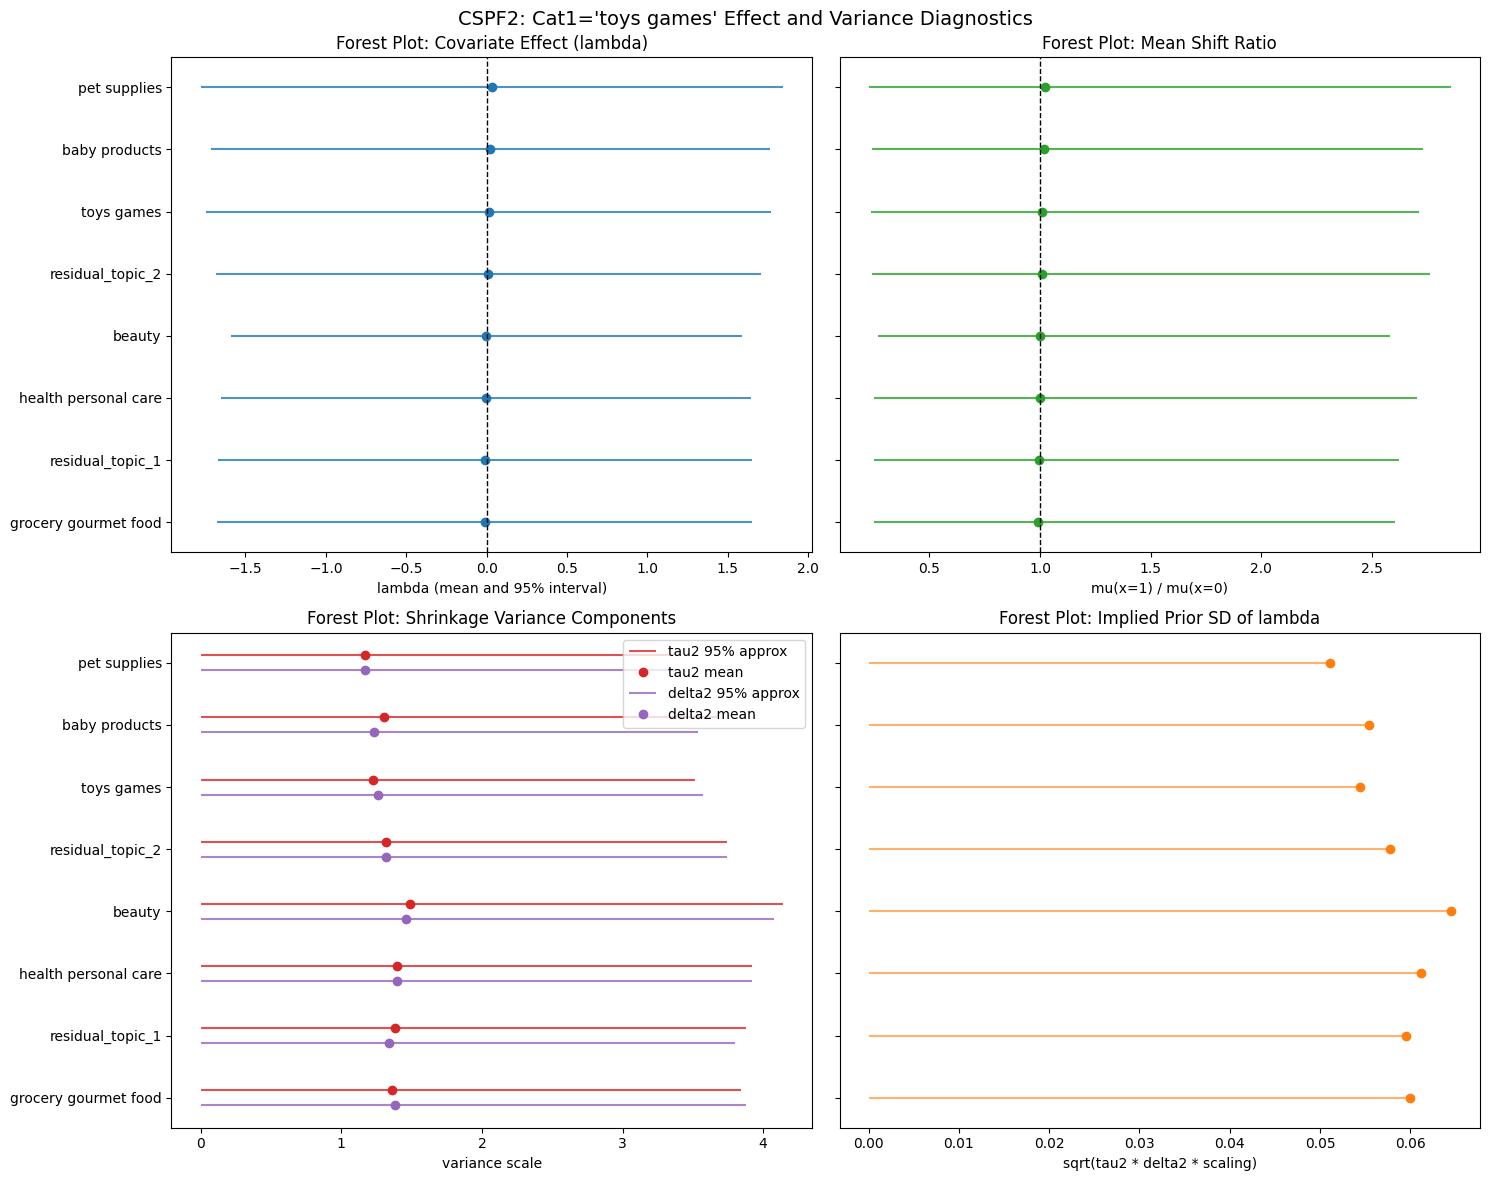

In [11]:
import matplotlib.pyplot as plt

plot_df = summary_df.copy().sort_values("lambda_mean", ascending=True).reset_index(drop=True)
y = np.arange(len(plot_df))

mu_ratio_l95 = np.log1p(np.exp(np.asarray(params["lambda_intercept_location"]) + plot_df["lambda_l95"].values)) / np.maximum(np.log1p(np.exp(np.asarray(params["lambda_intercept_location"]))), 1e-12)
mu_ratio_u95 = np.log1p(np.exp(np.asarray(params["lambda_intercept_location"]) + plot_df["lambda_u95"].values)) / np.maximum(np.log1p(np.exp(np.asarray(params["lambda_intercept_location"]))), 1e-12)

tau2_sd = np.sqrt(plot_df["tau2_var"].values)
tau2_l95 = np.maximum(plot_df["tau2_mean"].values - 1.96 * tau2_sd, 0.0)
tau2_u95 = plot_df["tau2_mean"].values + 1.96 * tau2_sd

delta2_sd = np.sqrt(plot_df["delta2_var"].values)
delta2_l95 = np.maximum(plot_df["delta2_mean"].values - 1.96 * delta2_sd, 0.0)
delta2_u95 = plot_df["delta2_mean"].values + 1.96 * delta2_sd

implied_prior_sd = np.sqrt(plot_df["implied_prior_var_lambda"].values)

fig, axes = plt.subplots(2, 2, figsize=(15, 12), sharey=True)

# 1) Lambda forest plot
ax = axes[0, 0]
ax.hlines(y, plot_df["lambda_l95"], plot_df["lambda_u95"], color="tab:blue", alpha=0.8)
ax.plot(plot_df["lambda_mean"], y, "o", color="tab:blue")
ax.axvline(0.0, linestyle="--", color="black", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["topic"])
ax.set_title("Forest Plot: Covariate Effect (lambda)")
ax.set_xlabel("lambda (mean and 95% interval)")

# 2) Mean-shift ratio forest plot
ax = axes[0, 1]
ax.hlines(y, mu_ratio_l95, mu_ratio_u95, color="tab:green", alpha=0.8)
ax.plot(plot_df["mu_ratio_x1_vs_x0"], y, "o", color="tab:green")
ax.axvline(1.0, linestyle="--", color="black", linewidth=1)
ax.set_title("Forest Plot: Mean Shift Ratio")
ax.set_xlabel("mu(x=1) / mu(x=0)")

# 3) Shrinkage components (tau2 and delta2)
ax = axes[1, 0]
ax.hlines(y + 0.12, tau2_l95, tau2_u95, color="tab:red", alpha=0.8, label="tau2 95% approx")
ax.plot(plot_df["tau2_mean"], y + 0.12, "o", color="tab:red", label="tau2 mean")
ax.hlines(y - 0.12, delta2_l95, delta2_u95, color="tab:purple", alpha=0.8, label="delta2 95% approx")
ax.plot(plot_df["delta2_mean"], y - 0.12, "o", color="tab:purple", label="delta2 mean")
ax.set_yticks(y)
ax.set_yticklabels(plot_df["topic"])
ax.set_title("Forest Plot: Shrinkage Variance Components")
ax.set_xlabel("variance scale")
ax.legend(loc="best")

# 4) Implied prior SD for lambda
ax = axes[1, 1]
ax.plot(implied_prior_sd, y, "o", color="tab:orange")
ax.hlines(y, 0, implied_prior_sd, color="tab:orange", alpha=0.6)
ax.set_title("Forest Plot: Implied Prior SD of lambda")
ax.set_xlabel("sqrt(tau2 * delta2 * scaling)")

fig.suptitle("CSPF2: Cat1='toys games' Effect and Variance Diagnostics", fontsize=14)
fig.tight_layout()
plt.show()

### Why these extra forest plots matter scientifically

- `lambda` forest plot identifies which topics are most strongly shifted by the category indicator and whether uncertainty excludes zero.
- The mean-ratio forest plot translates model coefficients to interpretable practical effect size on expected topic intensity.
- `tau2` and `delta2` forest plots expose how strongly each topic is globally versus locally shrunk.
- The implied prior-SD plot links shrinkage hyperparameters to the direct dispersion scale of the covariate effect.